<h1><center>Movie Recommendation System - Exploratory  Data Analysis</center></h1>

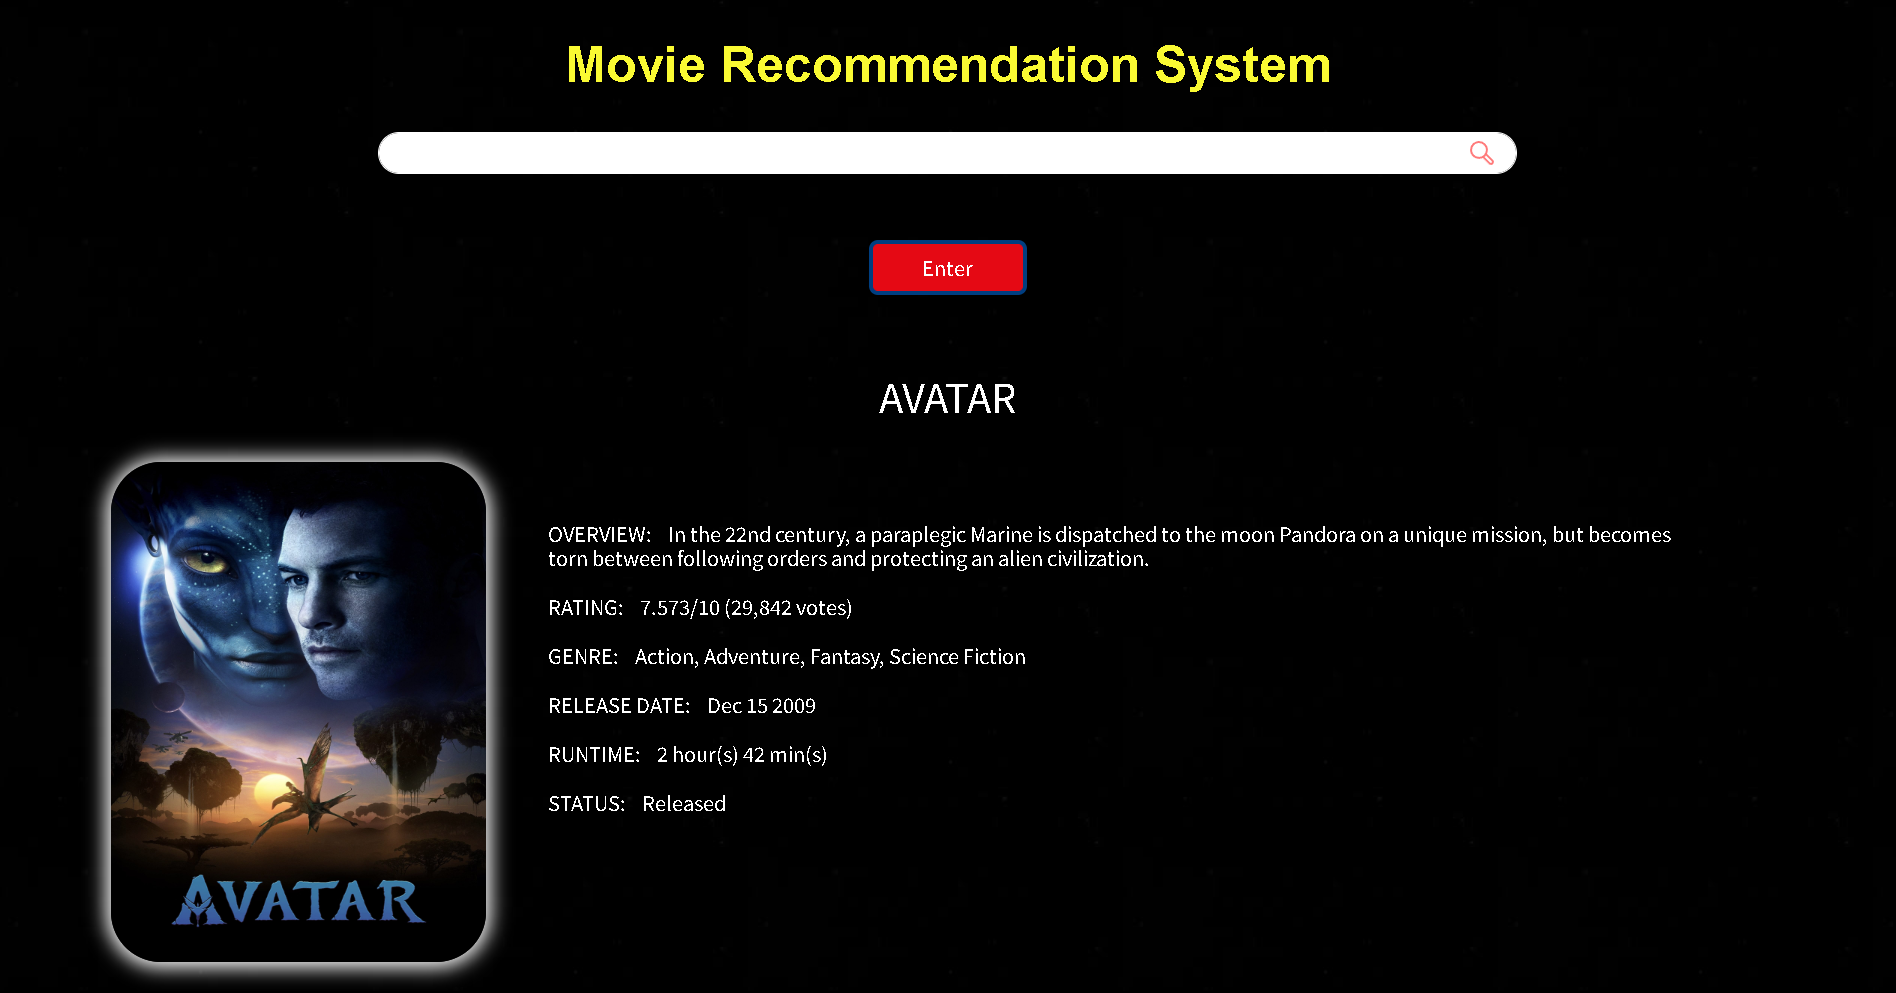

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Cosine Similarity Calculation
- Ranking and Recommendations
- Deployment

<p> We Will Perform upto Exploratory Data Analysis in this Notebook <p>

### 1) Problem statement
- This project Creates a content-based movie recommendation system using cosine similarity to address the challenge of personalizing movie recommendations based on user preferences and rich movie attributes.


### 2) Data Collection
- Dataset Source - <a href="https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies" target="_blank" rel="noopener"> Dataset Link </a>
<br>

- The data consists of 28 columns and 1162949 Records/Rows.

# 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Import the CSV Data as Pandas DataFrame

In [5]:
df = pd.read_csv('../data/TMDB_top50k_final.csv')

In [6]:
df.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,157336,Interstellar,The adventures of a group of explorers who mak...,"['Adventure', 'Drama', 'ScienceFiction']","['rescue', 'future', 'spacecraft', 'raceagains...","['MatthewMcConaughey', 'AnneHathaway', 'Michae...",['ChristopherNolan']
1,27205,Inception,"Cobb, a skilled thief who commits corporate es...","['Action', 'ScienceFiction', 'Adventure']","['mission', 'dreams', 'kidnapping', 'spy', 'al...","['LeonardoDiCaprio', 'JosephGordon-Levitt', 'K...",['ChristopherNolan']
2,24428,The Avengers,When an unexpected enemy emerges and threatens...,"['ScienceFiction', 'Action', 'Adventure']","['newyorkcity', 'superhero', 'shield', 'basedo...","['RobertDowneyJr.', 'ChrisEvans', 'MarkRuffalo']",['JossWhedon']
3,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,"['Action', 'Crime', 'Thriller']","['sadism', 'chaos', 'secretidentity', 'crimefi...","['ChristianBale', 'HeathLedger', 'AaronEckhart']",['ChristopherNolan']
4,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","['Action', 'Adventure', 'Fantasy', 'ScienceFic...","['paraplegic', 'attachmenttonature', 'culturec...","['SamWorthington', 'ZoeSaldaña', 'SigourneyWea...",['JamesCameron']


### Shape of the Dataset

In [7]:
df.shape

(50000, 7)

# 2.2 Dataset Information

- Director_Name    :Movie director's name
- Actor_1_Name     : Primary lead actor/actress
- Actor_2_Name     : Secondary lead actor/actress
- Actor_3_Name     : Tertiary actor/actress
- Genres           : Movie's thematic categories
- Movie_Title      : Title of the movie
- Combined_Feature : Aggregate representation for recommendation

### 3). Data Checks to perform

- Checking Missing values
- Checking Duplicates
- Checking data type
- Checking the number of unique values of each column
- Checking statistics of data set
- Checking Categorical and Numerical Attributes
- Checking various categories present in the different categorical column

### 3.1 Check Missing values

In [8]:
df.isnull().sum()

movie_id      0
title         0
overview    167
genres        0
keywords      0
cast          0
crew          0
dtype: int64

## Insights:

- There are no Missing Values in the dataset

### 3.2 Check Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

## Insights:

- There are no duplicates  values in the data set

### 3.3 Check data types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  50000 non-null  int64
 1   title     50000 non-null  str  
 2   overview  49833 non-null  str  
 3   genres    50000 non-null  str  
 4   keywords  50000 non-null  str  
 5   cast      50000 non-null  str  
 6   crew      50000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 2.7 MB


## Insights:

- All Features are in Object Datatype

### 3.4 Checking the number of unique values of each column

In [11]:
df.nunique()

movie_id    50000
title       46170
overview    49751
genres       5554
keywords    37090
cast        47736
crew        19054
dtype: int64

## Insights:

- All Features are having Number of Classes

### 3.5 Checking statistics of data set

In [12]:
df.describe()

,movie_id
count,5.000000e+04
mean,2.722036e+05
std,3.286182e+05
min,2.000000e+00
25%,3.036525e+04
50%,8.698250e+04
75%,4.474002e+05
max,1.618945e+06


### 3.5 Categorical and Numerical Attributes

In [13]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']

We have 0 categorical features : []


## Insights:

- All are Categorical Features (No Numerical Attributes)

### 3.6 Checking Various Categories Present in the Different Categorical Column

In [15]:
print("Categories in Directors:     ",end=" " )
print(df['crew'].unique())

print("\nCategories in keywords:  ",end=" ")
print(df['keywords'].unique())

print("\nCategories in cast:",end=" " )
print(df['cast'].unique())

print("\nCategories in Genres:     ",end=" " )
print(df['genres'].unique())

Categories in Directors:      <StringArray>
[ '['ChristopherNolan']',        '['JossWhedon']',      '['JamesCameron']',
         '['TimMiller']',          '['JoeRusso']',      '['DavidFincher']',
     '['FrankDarabont']',  '['QuentinTarantino']',         '['JamesGunn']',
    '['RobertZemeckis']',
 ...
      '['DavidSilberg']',       '['RobertFrank']', '['WitoldLeszczyński']',
        '['MarcusCole']',    '['KeiichiroSaito']',        '['AnneFassio']',
          '['JackWebb']',          '['UgoChiti']',   '['AnnabelGillings']',
     '['JamesMorrison']']
Length: 19054, dtype: str

Categories in keywords:   <StringArray>
['['rescue', 'future', 'spacecraft', 'raceagainsttime', 'artificialintelligence(a.i.)', 'nasa', 'timewarp', 'dystopia', 'expedition', 'spacetravel', 'wormhole', 'famine', 'hibernation', 'blackhole', 'quantummechanics', 'familyrelationships', 'space', 'robot', 'astronaut', 'scientist', 'singlefather', 'farmer', 'spacestation', 'spaceadventure', 'timeparadox', 'time-manipulat

## Insights:

- There are Alot of Classes in each Feature

### 4). Exploratory Data Analysis ( Visualization )

## 4.1 Genre Distribution

In [16]:
genre_df = df['genres'].str.split(' ', expand=True).stack().reset_index(level=1, drop=True).rename('genre')
genre_counts = genre_df.value_counts().tolist()
unique_genres = genre_df.unique().tolist()

In [17]:
print(type(unique_genres[0]))
print(unique_genres[:10])

<class 'str'>
["['Adventure',", "'Drama',", "'ScienceFiction']", nan, "['Action',", "'ScienceFiction',", "'Adventure']", "['ScienceFiction',", "'Action',", "'Crime',"]


In [18]:
unique_genres_clean = []
genre_counts_clean = []

for g, c in zip(unique_genres, genre_counts):
    if pd.notna(g) and g != '':
        unique_genres_clean.append(g)
        genre_counts_clean.append(c)

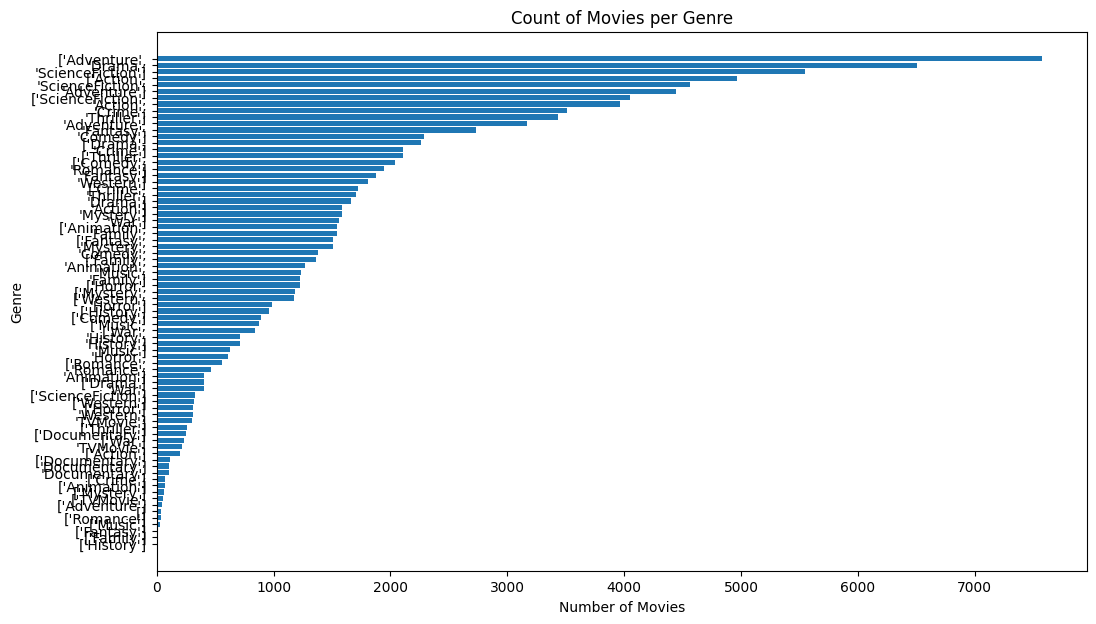

In [19]:
plt.figure(figsize=(12,7))
plt.barh(unique_genres_clean, genre_counts_clean)
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Count of Movies per Genre")
plt.gca().invert_yaxis()
plt.show()

## 4.2 Top 10 Actors (Actor_1)

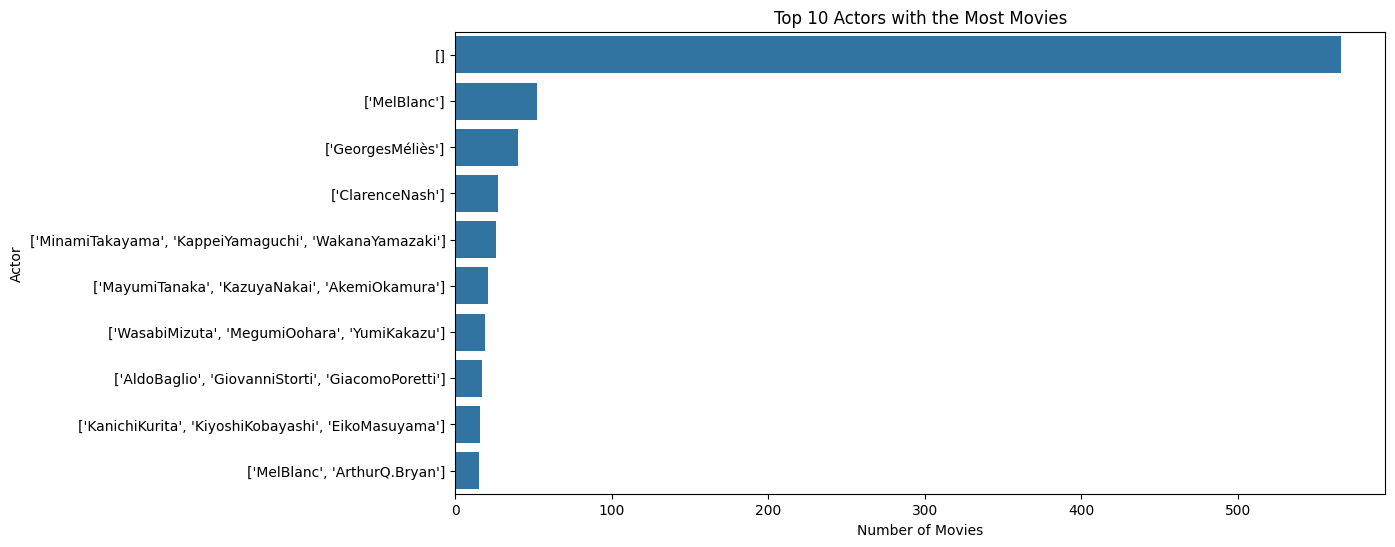

In [20]:
top_actors = df[df['cast'] != 'unknown']['cast'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title("Top 10 Actors with the Most Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Actor")
plt.show()

## 4.3 Top 10 Genres

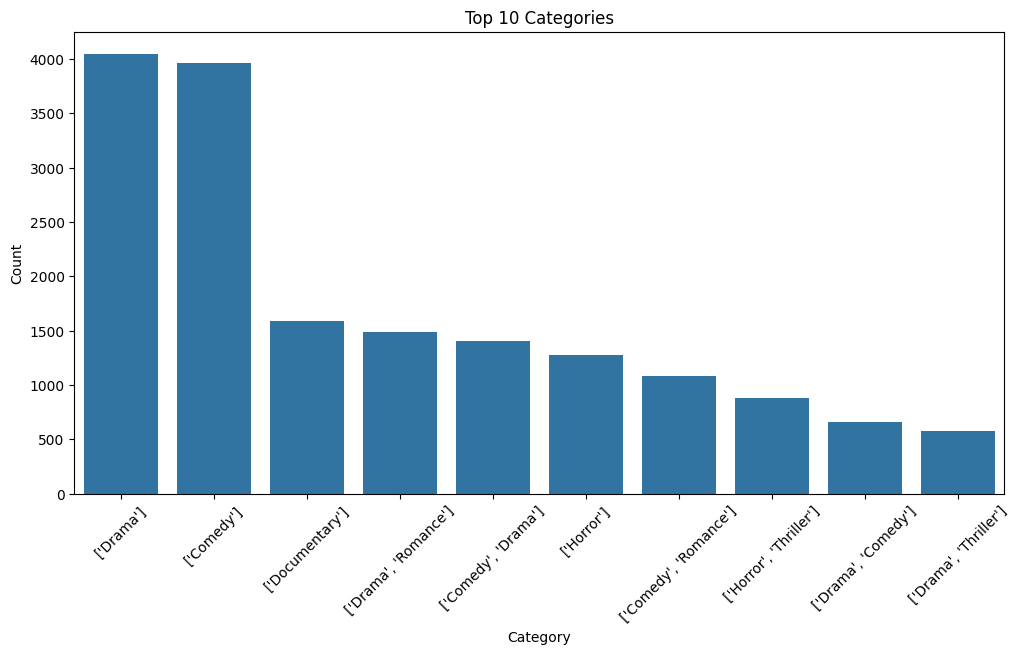

In [21]:
top_categories = df['genres'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.xticks(rotation=45)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title(f'Top {10} Categories')
plt.show()

## 4.4 Top Directors 

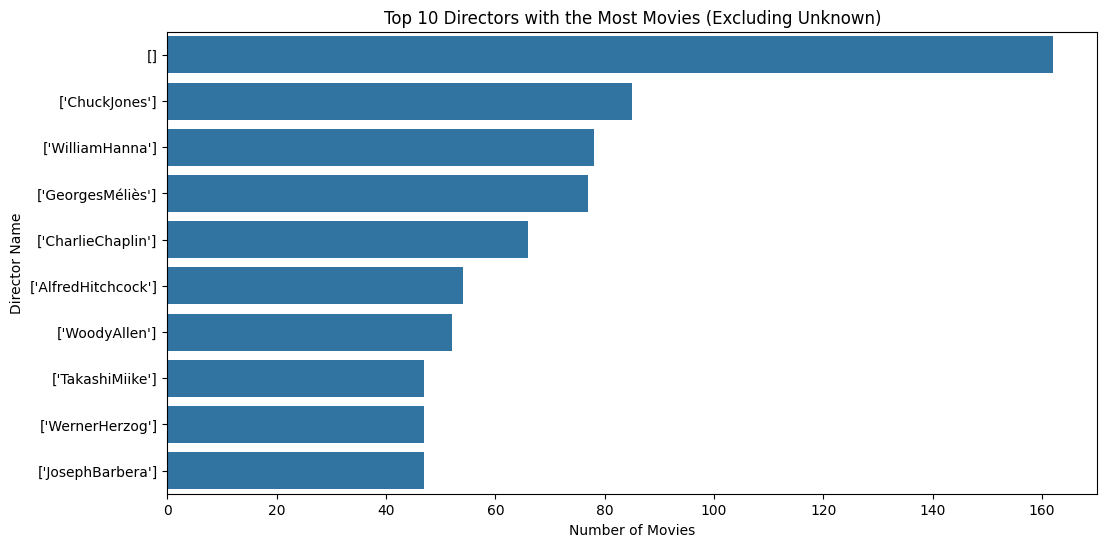

In [22]:
filtered_df = df[df['crew'] != 'unknown']
top_directors = filtered_df['crew'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.xlabel('Number of Movies')
plt.ylabel('Director Name')
plt.title(f'Top {10} Directors with the Most Movies (Excluding Unknown)')
plt.show()

## 4.5 Movie Titles Word Cloud - Word Cloud

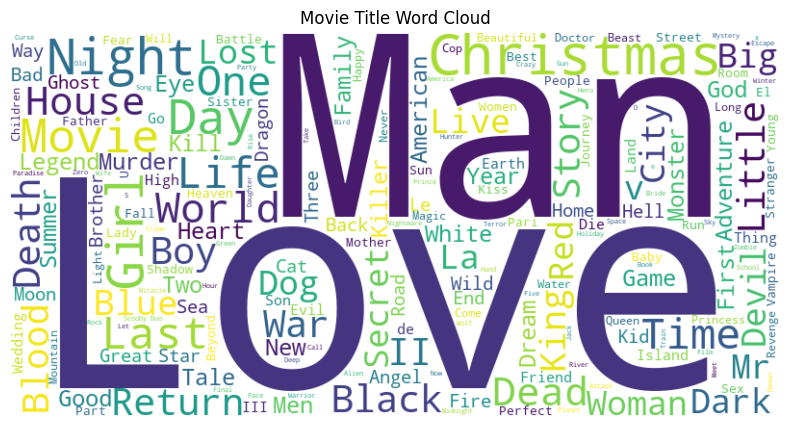

In [23]:
from wordcloud import WordCloud

wordcloud_text = ' '.join(df['title'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wordcloud_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Movie Title Word Cloud')
plt.show()

## Insights:

- Most Frequently Used Words: Love, Last, Man, Day

## 4.6 Distribution of Categorical and Numerical Features

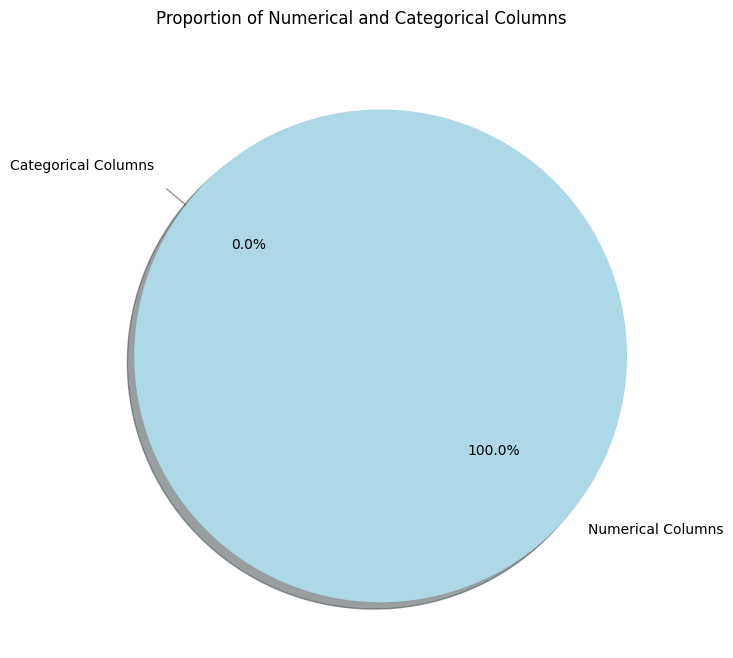

In [24]:
num_numerical_columns = len(numeric_features)
num_categorical_columns = len(categorical_features)

labels = ['Numerical Columns', 'Categorical Columns']
sizes = [num_numerical_columns, num_categorical_columns]
colors = ['lightblue', 'lightcoral']
explode = (0.1, 0)
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Proportion of Numerical and Categorical Columns')
plt.show()

## Insights:

- All are Categorical Attributes Only

## 4.7 Director-Actor Collaborations by Number of Movies

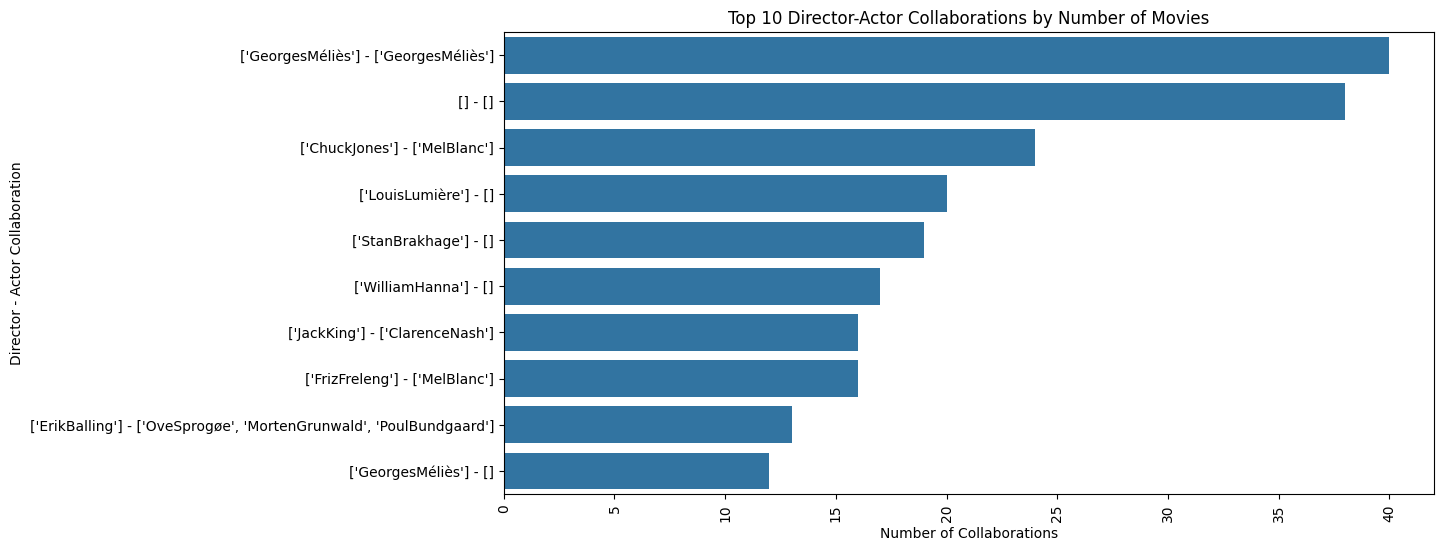

In [25]:
df['director_actor_collaboration'] = df['crew'] + ' - ' + df['cast']
collaboration_counts = df['director_actor_collaboration'].value_counts()
top_10_collaborations = collaboration_counts.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_collaborations.values, y=top_10_collaborations.index)
plt.xlabel('Number of Collaborations')
plt.ylabel('Director - Actor Collaboration')
plt.title('Top 10 Director-Actor Collaborations by Number of Movies')
plt.xticks(rotation=90)
plt.show()